# Demo Inference Service

Demo notebook for sending a prediction request to the deployed inference service, and visualizing the results.

## Requirements

In [2]:
! pip install numpy==1.26.4 einops==0.4.1 scipy==1.10.1 connected-components-3d monai[nibabel,pillow,ignite,tqdm,pydicom]====1.5.0 synapseclient

## Import utility functions

In [1]:
from utils import plot_input_scan, send_prediction_request, plot_results, plot_results_overlap

## Dataset

Download scan image from the [Multi-Atlas Labeling Beyond the Cranial Vault - Workshop and Challenge](https://www.synapse.org/Synapse:syn3193805/wiki/89480) dataset.

You must create a Synapse account and get Personal Access Token (PAT) to access the dataset.

```
pip install synapseclient

synapse get syn3553734

unzip Abdomen.zip
```

The data contains labels for 13 different organs. Check this link for additional details on the dataset: [Abdomen dataset](https://www.synapse.org/Synapse:syn3193805/wiki/217789).

- (1) spleen
- (2) right kidney
- (3) left kidney
- (4) gallbladder
- (5) esophagus
- (6) liver
- (7) stomach
- (8) aorta
- (9) inferior vena cava
- (10) portal vein and splenic vein
- (11) pancreas
- (12) right adrenal gland
- (13) left adrenal gland

## Port forwarding to inference service

1. Open your terminal and run the following command:
   
    `kubectl port-forward -n <namespace> service/dev-lifescience-swinunetr-<release-name> 8000:80`

2. Keep the Terminal Open: The port-forward command runs in the foreground. You must keep this terminal window open for the connection to remain active.

## Inference Parameters

In [2]:
# Path to the image file to send for prediction.
image_path = "./Abdomen/RawData/Training/img/img0001.nii.gz"

# Ground truth label file for the image.
label_path = "./Abdomen/RawData/Training/label/label0001.nii.gz"

# Filename to save the output prediction
output_path = "client_prediction.nii.gz"

# URL of the prediction inference service endpoint
service_url = "http://localhost:8000/predict/"

## Input view

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2025-08-04 10:51:45,765 - INFO - pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2025-08-04 10:51:49,784 - INFO - Input data shape: torch.Size([229, 229, 220])


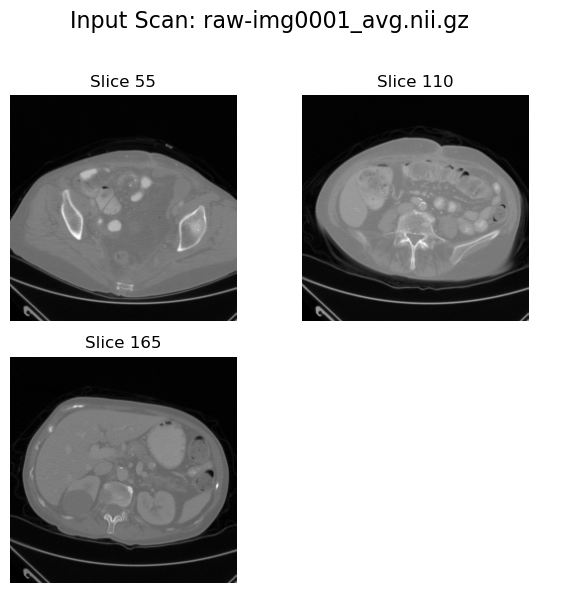

In [3]:
plot_input_scan(input_path=image_path, num_slices_to_plot=3)

## Send prediction request

Send a CT san to the inference service for prediction:

In [17]:
send_prediction_request(image_path=image_path, output_path=output_path, server_url=service_url)

INFO:utils:Attempting to send ../../data/inputs_nifti/LUNG1-001_input.nii.gz to http://localhost:8001/predict/
INFO:utils:Status Code: 200
INFO:utils:Success! Prediction saved to client_prediction.nii.gz


## Visualize results

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2025-08-04 10:52:08,516 - INFO - pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2025-08-04 10:52:10,516 - INFO - pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


Input data shape: torch.Size([1, 229, 229, 220])
Label data shape: torch.Size([14, 229, 229, 220])
Prediction data shape: torch.Size([14, 229, 229, 220])


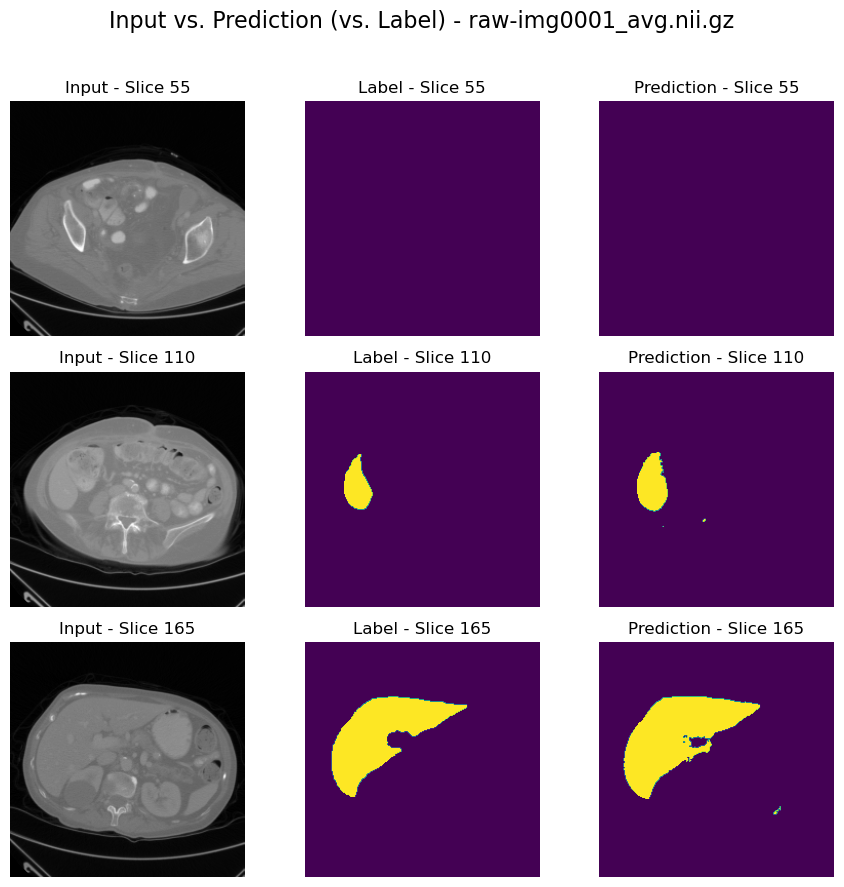

In [4]:
channel_idx = 6

plot_results(image_path, label_path, output_path, channel_idx=channel_idx, num_slices_to_plot=3)

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2025-08-04 10:53:00,148 - INFO - pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2025-08-04 10:53:02,367 - INFO - pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


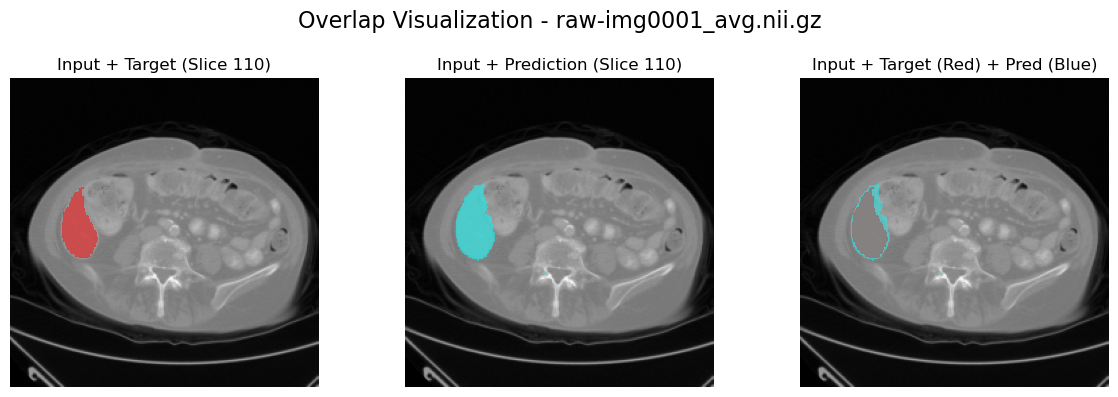

In [5]:
slice_to_plot = 110

plot_results_overlap(
    image_path, label_path, output_path, channel_idx=channel_idx, slice_to_plot=slice_to_plot
)

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2025-08-04 10:53:42,010 - INFO - pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2025-08-04 10:53:44,120 - INFO - pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


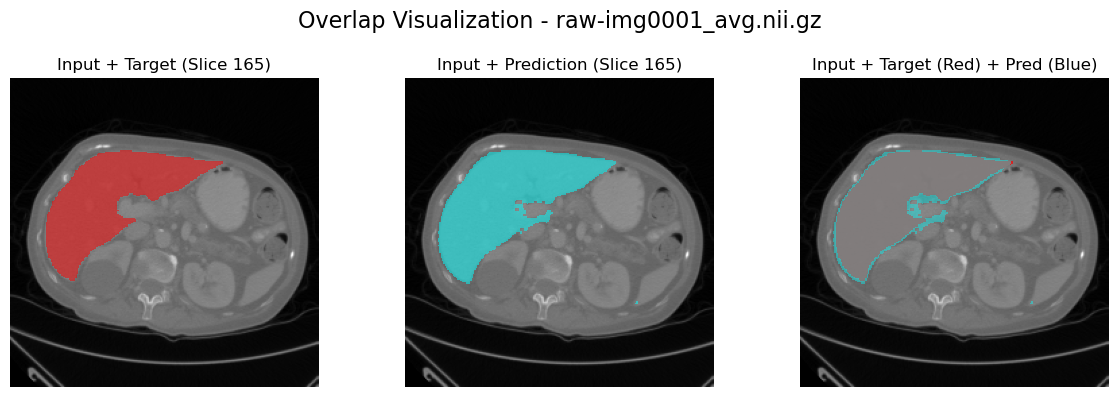

In [6]:
channel_idx = 6
slice_to_plot = 165

plot_results_overlap(
    image_path, label_path, output_path, channel_idx=channel_idx, slice_to_plot=slice_to_plot
)